In [1]:
import pandas as pd
import os

In [2]:
output_folder = r""

In [3]:
lvl0_csv_path = r"C:\Users\leroquan\Downloads\eddy_catalogues_lvl0\eddy_catalogues_lvl0\lvl0_20230301_20230308.csv"
lake_csv_path = r"C:\Users\leroquan\Downloads\eddy_catalogues_lvl0\eddy_catalogues_lvl0\lake_characteristics_20230301_20230308.csv"

In [4]:
df_lvl0 = pd.read_csv(lvl0_csv_path).set_index('date')
df_lake = pd.read_csv(lake_csv_path).set_index('date')

In [5]:
df_lvl0.head()

,id,time_index,depth_index,eddy_index,depth_[m],xc,yc,surface_area_[m2],volume_slice_[m3],rotation_direction,kinetic_energy_eddy_[MJ],kinetic_energy_lake_[MJ],mean_temperature_eddy_[°C],mean_temperature_lake_[°C],i_eddy_cells,j_eddy_cells,task_load_time_sec,task_compute_time_sec,task_total_time_sec,pixels_in_task
date,,,,,,,,,,,,,,,,,,,,
2023-03-01 00:40:00,0,0,0,0,-0.25,76.000000,132.500000,10000.0,2500.0,clockwise,0.0,0.002738,0.0,22.19058,"75.0,75.0,76.0,77.0","132.0,133.0,133.0,133.0",24.419532,193.050907,217.470439,25
2023-03-01 00:40:00,0,0,0,1,-0.25,679.111111,428.944444,17500.0,4375.0,anticlockwise,0.0,0.002738,0.0,22.19058,"678.0,678.0,679.0,679.0,679.0,680.0,680.0","428.0,429.0,428.0,429.0,430.0,428.0,429.0",24.419532,193.050907,217.470439,25
2023-03-01 00:40:00,0,0,0,2,-0.25,176.346154,238.730769,17500.0,4375.0,anticlockwise,0.0,0.002738,0.0,22.19058,"175.0,176.0,176.0,176.0,176.0,177.0,177.0","238.0,237.0,238.0,239.0,240.0,238.0,239.0",24.419532,193.050907,217.470439,25
2023-03-01 00:40:00,0,0,0,3,-0.25,1019.000000,361.500000,7500.0,1875.0,clockwise,0.0,0.002738,0.0,22.19058,"1018.0,1019.0,1020.0","361.0,362.0,362.0",24.419532,193.050907,217.470439,25
2023-03-01 00:40:00,0,0,0,4,-0.25,268.500000,215.375000,12500.0,3125.0,clockwise,0.0,0.002738,0.0,22.19058,"268.0,268.0,268.0,269.0,269.0","214.0,215.0,216.0,215.0,216.0",24.419532,193.050907,217.470439,25


# Entire lake analysis

In [6]:
eddy_ke = df_lvl0.groupby('date').sum()['kinetic_energy_eddy_[MJ]']

In [7]:
lake_ke = df_lake.groupby('date').sum()['kinetic_energy_[MJ]']

(1000*eddy_ke).to_csv(r"D:\04-Geneva_dummy\03_24h-wind_extended\params_06\eddy_catalogues_lvl0\ke_eddy.csv")

<Axes: xlabel='date'>

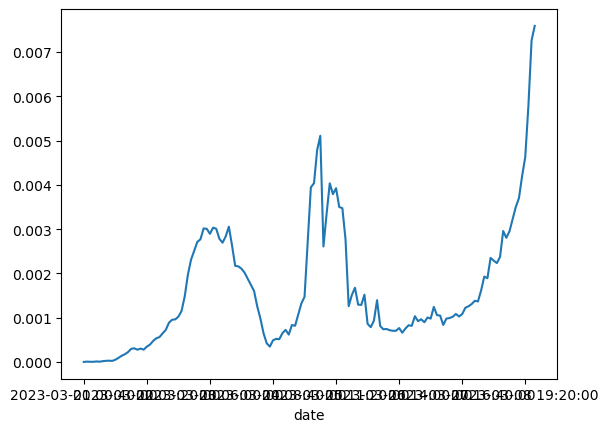

In [8]:
eddy_ke.plot()

In [9]:
import matplotlib.pyplot as plt

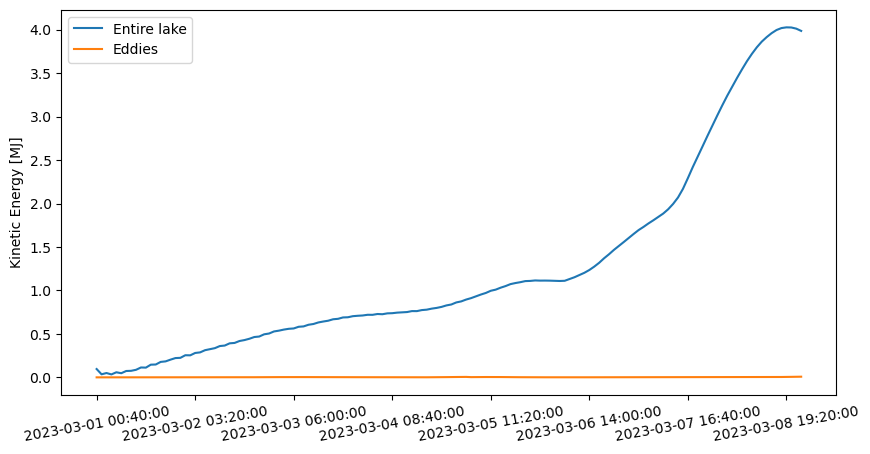

In [10]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1, 1, 1)
lake_ke.plot(label='Entire lake')
eddy_ke.plot(label='Eddies')
plt.ylabel('Kinetic Energy [MJ]')
plt.xlabel('')
plt.xticks(rotation=10)
plt.legend()
#ax.set_yscale('log')
#fig.savefig(os.path.join(output_folder, "kinetic_energy_whole_lake.png"))

In [11]:
percentage_total_ke = 100 * eddy_ke / lake_ke[lake_ke.index.isin(eddy_ke.index)]

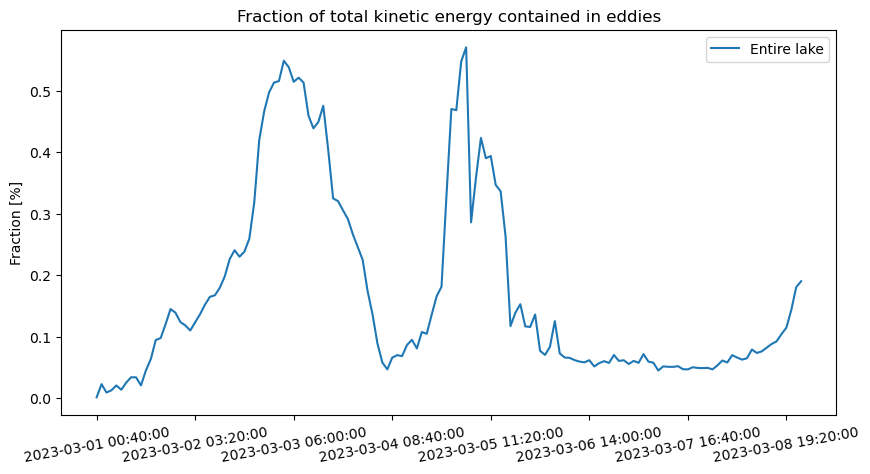

In [12]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1, 1, 1)
percentage_total_ke.plot(label='Entire lake')
plt.title('Fraction of total kinetic energy contained in eddies')
plt.ylabel('Fraction [%]')
plt.xlabel('')
plt.xticks(rotation=10)
plt.legend()

# Surface analysis

In [13]:
df_lvl0_surf = df_lvl0[df_lvl0['depth_index']==0]
df_lake_surf = df_lake[df_lake['depth_index']==0]

In [14]:
surf_lvl0_sum = df_lvl0_surf.groupby('date').sum()

surf_lvl0_sum['kinetic_energy_eddy_[MJ]'].reset_index().to_csv(r'D:\04-Geneva_dummy\03_24h-wind_extended\energy_analysis\surface_eddy_ke')

df_lake_surf[df_lake_surf.index.isin(surf_lvl0_sum.index)]['kinetic_energy_[MJ]'].reset_index().to_csv(r'D:\04-Geneva_dummy\03_24h-wind_extended\energy_analysis\ke_total_surface.csv')

In [15]:
surf_lvl0_sum['percentage_total_ke_[%]'] = 100 * surf_lvl0_sum['kinetic_energy_eddy_[MJ]'] / df_lake_surf[df_lake_surf.index.isin(surf_lvl0_sum.index)]['kinetic_energy_[MJ]']

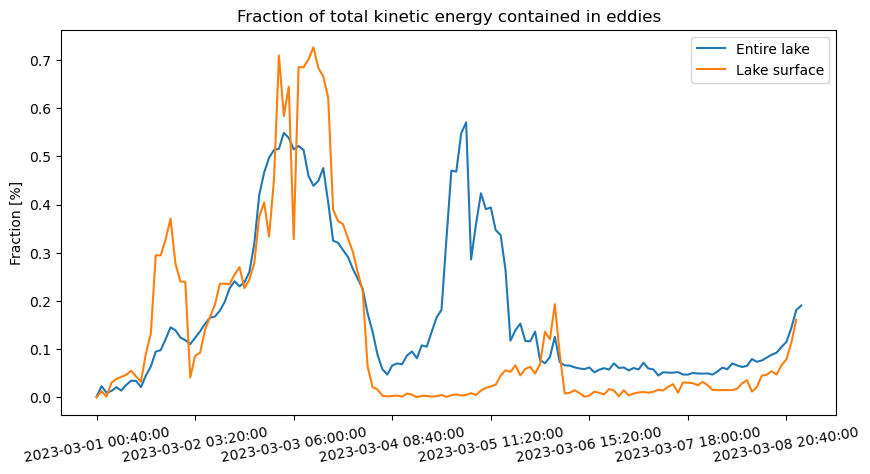

In [16]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1, 1, 1)
percentage_total_ke.plot(label='Entire lake')
surf_lvl0_sum['percentage_total_ke_[%]'].plot(label='Lake surface')
plt.title('Fraction of total kinetic energy contained in eddies')
plt.ylabel('Fraction [%]')
plt.xlabel('')
plt.xticks(rotation=10)
plt.legend()
#fig.savefig(os.path.join(output_folder, "fraction_ke_in_eddies.png"))

(array([-20.,   0.,  20.,  40.,  60.,  80., 100., 120., 140., 160.]),
 [Text(-20.0, 0, '2023-03-07 22:00:00'),
  Text(0.0, 0, '2023-03-01 00:40:00'),
  Text(20.0, 0, '2023-03-02 03:20:00'),
  Text(40.0, 0, '2023-03-03 06:00:00'),
  Text(60.0, 0, '2023-03-04 08:40:00'),
  Text(80.0, 0, '2023-03-05 11:20:00'),
  Text(100.0, 0, '2023-03-06 15:20:00'),
  Text(120.0, 0, '2023-03-07 18:00:00'),
  Text(140.0, 0, '2023-03-08 20:40:00'),
  Text(160.0, 0, '')])

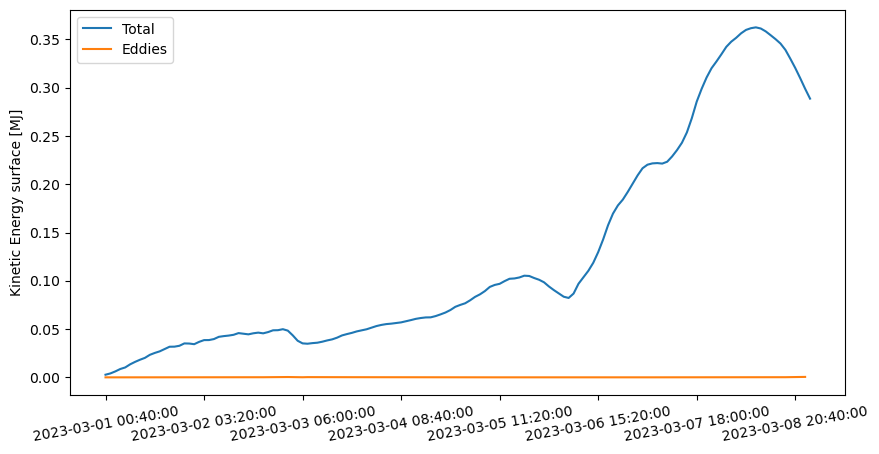

In [17]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1, 1, 1)
df_lake_surf['kinetic_energy_[MJ]'].plot(label='Total')
surf_lvl0_sum['kinetic_energy_eddy_[MJ]'].plot(label='Eddies')
plt.legend()
plt.ylabel('Kinetic Energy surface [MJ]')
plt.xlabel('')
plt.xticks(rotation=10)
#ax.set_yscale('log')
#fig.savefig(os.path.join(output_folder, "kinetic_energy_surface.png"))

<Axes: xlabel='date'>

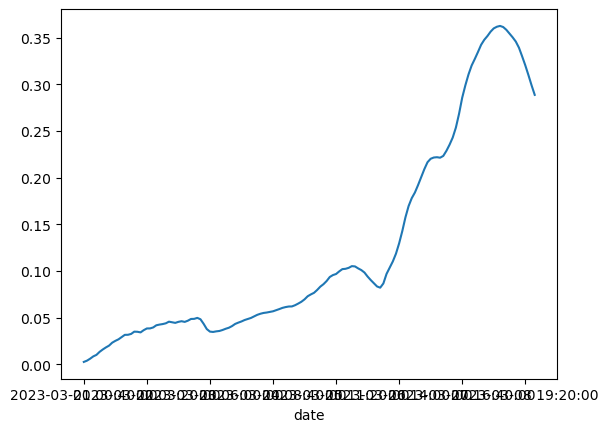

In [18]:
df_lake_surf['kinetic_energy_[MJ]'].plot(label='Entire lake')

<Axes: xlabel='date'>

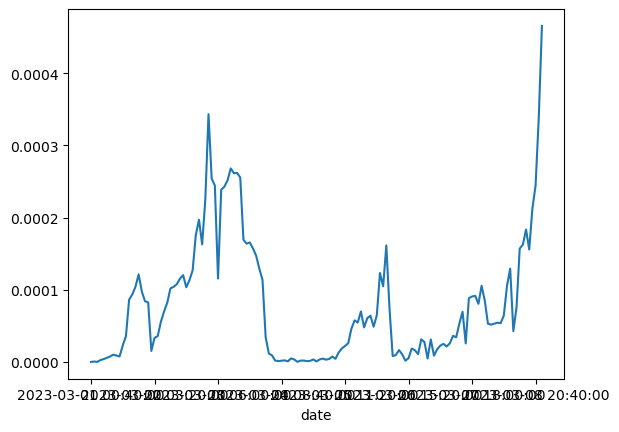

In [19]:
surf_lvl0_sum['kinetic_energy_eddy_[MJ]'].plot()

<Axes: xlabel='date'>

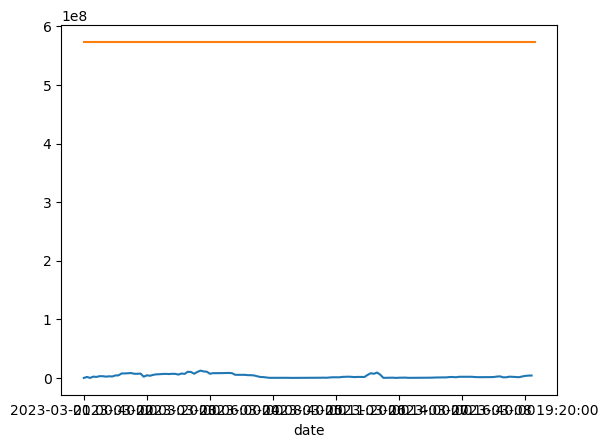

In [20]:
surf_lvl0_sum['surface_area_[m2]'].plot()
df_lake_surf['surface_area_[m2]'].plot()

# Depth analysis

In [21]:
eddy_ke_by_depth_and_date = df_lvl0.groupby(['time_index', 'depth_[m]'])['kinetic_energy_eddy_[MJ]'].sum().reset_index()

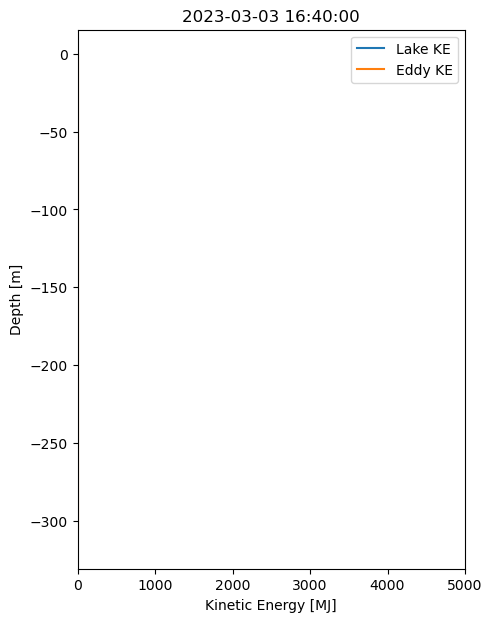

In [23]:
t_idx = 48
fig, ax = plt.subplots(figsize=(5,7))

# Lake KE profile
df_lake[df_lake['time_index']==t_idx].plot(
    x='kinetic_energy_[MJ]', y='depth_[m]', ax=ax, label='Lake KE'
)

# Eddy KE profile
eddy_ke_by_depth_and_date[eddy_ke_by_depth_and_date['time_index']==t_idx].plot(
    x='kinetic_energy_eddy_[MJ]', y='depth_[m]', ax=ax, label='Eddy KE'
)

ax.set_xlabel("Kinetic Energy [MJ]")
ax.set_ylabel("Depth [m]")
ax.legend()
plt.title(df_lake[df_lake['time_index']==t_idx].index[0])
ax.set_xlim(left=0, right=5000)
plt.show()
str_time = df_lake[df_lake['time_index']==t_idx].index[0].replace(' ','_').replace(':','-')
#fig.savefig(os.path.join(output_folder, "profiles_ke", f"kinetic_energy_profile_{str_time}.png"))